# Comparison
In this notebook we compare the ROMs we learned in the previous notebooks.

## Imports

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
import pickle
import seaborn as sns
import pandas as pd

import time
tStart_notebook = time.time()

import sys
sys.path.insert(0, '../../../source')
sys.path.insert(0, '../../../source/fom')

%load_ext autoreload
%autoreload 2

import opinf as opinf
from fom.FomCubicHeatFEniCSx import FomCubicHeat
from polyrom.PolyRomIntrusiveTime import PolyRomIntrusiveTime
from matrixSetup.FoodTime import FoodTime
from opinf_schemes.NestedOpInf import NestedOpInf as NestedOpInf

## User settings

In [2]:
training_path = "/storage/nicole/git-save-data/opinf/cubic-heat/paper/"

## Setup

### test data

In [3]:
with open("/storage/nicole/git-save-data/opinf/cubic-heat/paper/data/trainingdata", "rb") as file:
    Xi_test, U_para_test, compute_time_fom = pickle.load(file)

### FOM

In [4]:
nFE = U_para_test[0].shape[0]
grid_t = np.arange(0, 1+0.001, 0.001)

fom = FomCubicHeat(nFE, grid_t)
fom.timestepping = "CN"

### Reduced space

In [5]:
with open(training_path + "training", "rb") as file:
        Xi_train, U_train, VR, transformer, grid_t_train, U_para, final_training_time = pickle.load(file)

# get the shapes
nFE = VR.shape[0]
nRB = VR.shape[1]
n_para = Xi_train.shape[0]
K_train = grid_t_train.shape[0]

# set up the matrix handler
matrixhandler = FoodTime(VR, fom, transformer=transformer, Xi_train = Xi_train) # FD time derivative

## Reduced models

In [6]:
n_models = 3
ROMq = np.zeros((nRB, n_models), dtype=object)
names = np.zeros(n_models+1, dtype=object)
names[-1] = "projection"

### Intrusive ROM

In [7]:
names[0] = "intrusive" 

for n in range(nRB):
    ROMq[n, 0] = PolyRomIntrusiveTime(VR[:, :n+1], fom, transformer=transformer)
    ROMq[n, 0].decompose()

### Regularized OpInf
We use the ROM that was trained specifically for `r=5`

In [8]:
# with open(training_path + "trained_regularized/trained_regularized_n5_s1_test51", "rb") as file:
#     qInferred, training_path_loaded, condition_no_reg, training_time_reg, __, __ = pickle.load(file)

# if training_path_loaded != training_path + "training":
#     raise RuntimeError("Model trained on wrong training data")

# i_model = 1
# names[i_model] = "regularized OpInf"

# for n in range(nRB):
#     inferred_sub = matrixhandler.blow_down(big_matrix=qInferred[-1], nRB=nRB, indices=[*range(n+1)])
#     ROMq[n, i_model] = matrixhandler.get_reduced_model(A_new = inferred_sub, 
#                                                 indices = [*range(n+1)], 
#                                                 indices_testspace = [*range(n+1)])
    
# print("training time:", training_time_reg)

In [9]:
i_model = 1
names[i_model] = "regularized OpInf"

for n in range(nRB):

    with open(training_path + f"trained_regularized/trained_regularized_n{n+1}_s1_test51", "rb") as file:
        qInferred, training_path_loaded, condition_no_reg, training_time_reg, __, __ = pickle.load(file)

    if training_path_loaded != training_path + "training":
        raise RuntimeError("Model trained on wrong training data")

    # inferred_sub = matrixhandler.blow_down(big_matrix=qInferred[-1], nRB=nRB, indices=[*range(n+1)])
    ROMq[n, i_model] = matrixhandler.get_reduced_model(A_new = qInferred[-1], 
                                                indices = [*range(n+1)], 
                                                indices_testspace = [*range(n+1)])
    
print("training time:", training_time_reg)

training time: 52.70863223075867


### Nested OpInf

Again, we have two choices. We first load the model that was trained for r=5 and take its Galerkin projection onto the smaller reduced subspaces. Then we also look at the ROMs we got as in-between steps during the learing process.

In [10]:
i_model = 2
names[i_model] = "nested OpInf"

with open(training_path + "trained_nested/trained_nested_n5_i5", "rb") as file:
    qInferred, training_path_loaded, condition_no_nest, training_time_nest, __, __ = pickle.load(file)

# with open(training_path + "trained_nested/trained_nested_n5", "rb") as file:
#     qInferred, training_path_loaded, condition_no_nest, training_time_nest = pickle.load(file)

if training_path_loaded != training_path + "training":
    raise RuntimeError("Model trained on wrong training data")

for n in range(nRB):
    #inferred_sub = matrixhandler.blow_down(big_matrix=qInferred[-1], nRB=nRB, indices=[*range(n+1)])
    inferred_sub = qInferred[n]
    ROMq[n, i_model] = matrixhandler.get_reduced_model(A_new = inferred_sub, 
                                                indices = [*range(n+1)], 
                                                indices_testspace = [*range(n+1)])

print("training time:", sum(training_time_nest))

training time: 39.80457353591919


## Comparison -- all parameters

In [11]:
errors = np.zeros((201, n_models+1, nRB, grid_t.shape[0]))
test_time = np.zeros((201, n_models, nRB))

for i_test in range(201):

    # initialization
    U_test = U_para_test[i_test]
    para_test = Xi_test[i_test, :]
    print("test parameter:", para_test)

    for n in range(nRB):

        # ROM
        for i in range(n_models):
            tStart = time.time()
            sol_RB = ROMq[n, i].solve_ivp(grid_t = grid_t, para = para_test)
            test_time[i_test, i, n] = time.time()-tStart

            Sol_RB = ROMq[n, i].toFO(sol_RB)
            errors[i_test, i, n, :] = fom.norm_over_time(Sol_RB - U_test, axis = 0)

        # projection
        i = -1
        if transformer is None:
            proj = VR[:, :n+1].T @ fom.M @ U_test
        else:
            proj = VR[:, :n+1].T @ fom.M @ transformer.transform(U_test)
        Proj = ROMq[n,0].toFO(proj) 
        errors[i_test, i, n, :] = fom.norm_over_time(Proj - U_test, axis = 0)

test parameter: [0.001]
test parameter: [0.00102329]
test parameter: [0.00104713]
test parameter: [0.00107152]
test parameter: [0.00109648]
test parameter: [0.00112202]
test parameter: [0.00114815]
test parameter: [0.0011749]
test parameter: [0.00120226]
test parameter: [0.00123027]
test parameter: [0.00125893]
test parameter: [0.00128825]
test parameter: [0.00131826]
test parameter: [0.00134896]
test parameter: [0.00138038]
test parameter: [0.00141254]
test parameter: [0.00144544]
test parameter: [0.00147911]
test parameter: [0.00151356]
test parameter: [0.00154882]
test parameter: [0.00158489]
test parameter: [0.00162181]
test parameter: [0.00165959]
test parameter: [0.00169824]
test parameter: [0.0017378]
test parameter: [0.00177828]
test parameter: [0.0018197]
test parameter: [0.00186209]
test parameter: [0.00190546]
test parameter: [0.00194984]
test parameter: [0.00199526]
test parameter: [0.00204174]
test parameter: [0.0020893]
test parameter: [0.00213796]
test parameter: [0.0021

In [12]:
reference_norm = np.zeros((201, grid_t.shape[0]))
for i in range(201):
    reference_norm[i, :] = fom.norm_over_time(U_para_test[i])

Text(0, 0.5, 'relative error')

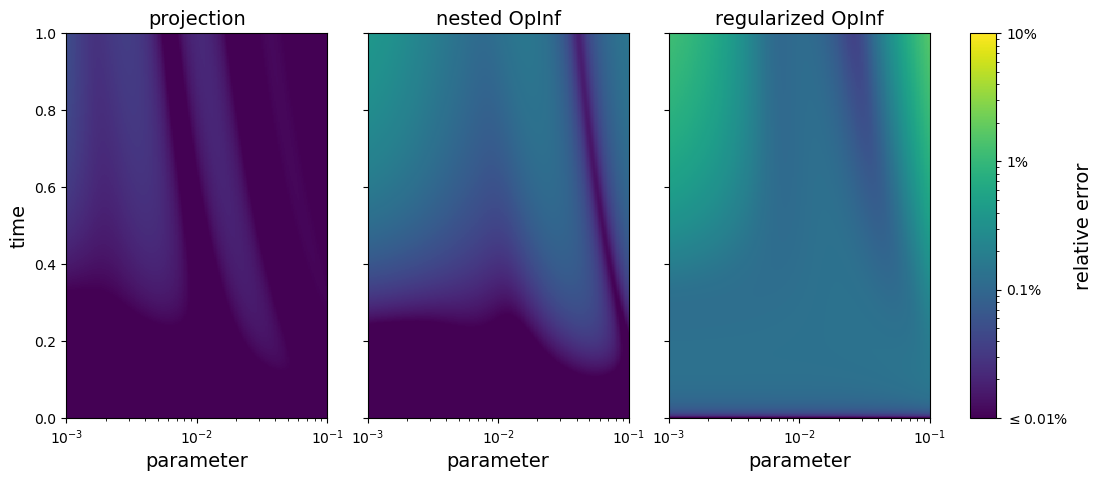

In [13]:
# relative error
n = 4

fig, axs = plt.subplots(1, 4, figsize=(12, 5), width_ratios=[1, 1, 1, 0.1])
fontsize = 14

X, Y = np.meshgrid(Xi_test, grid_t)

for i, i_model in enumerate([3, 2, 1]):
    cs = axs[i].pcolormesh(X, Y, 100 * errors[:, i_model, n, :].T /reference_norm.T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs.set_clim(vmin=1e-2, vmax=10)

    axs[i].set_xscale("log")
    axs[i].set_xlim(Xi_test[0, 0], Xi_test[-1, 0])
    axs[i].set_ylim(grid_t[0], grid_t[-1])
    axs[i].set_title(names[i_model], fontsize = fontsize)
    axs[i].set_xlabel("parameter", fontsize = fontsize)
    
axs[0].set_ylabel("time", fontsize=fontsize)
axs[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])
axs[2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])

cbar = fig.colorbar(cs, cax=axs[-1])
cbar.ax.set_yticks([0.01, 0.1, 1, 10], ["$\leq$0.01%", "0.1%", "1%", "10%"])
cbar.ax.set_ylabel("relative error", fontsize = fontsize)

# fig.savefig(f"/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/error2D_rel_n{n+1}_proj.png", bbox_inches = "tight")

Text(0, 0.5, 'relative error')

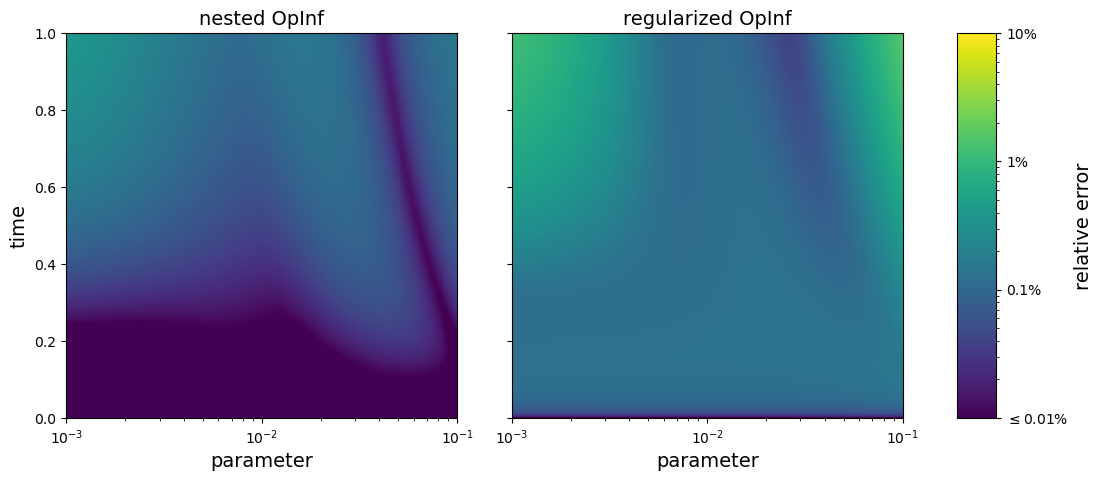

In [14]:
# relative error
n = 4

fig, axs = plt.subplots(1, 3, figsize=(12, 5), width_ratios=[1, 1, 0.1])
fontsize = 14

X, Y = np.meshgrid(Xi_test, grid_t)

for i, i_model in enumerate([2, 1]):
    cs = axs[i].pcolormesh(X, Y, 100 * errors[:, i_model, n, :].T /reference_norm.T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs.set_clim(vmin=1e-2, vmax=10)

    axs[i].set_xscale("log")
    axs[i].set_xlim(Xi_test[0, 0], Xi_test[-1, 0])
    axs[i].set_ylim(grid_t[0], grid_t[-1])
    axs[i].set_title(names[i_model], fontsize = fontsize)
    axs[i].set_xlabel("parameter", fontsize = fontsize)
    
axs[0].set_ylabel("time", fontsize=fontsize)
axs[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])
axs[2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])

cbar = fig.colorbar(cs, cax=axs[-1])
cbar.ax.set_yticks([0.01, 0.1, 1, 10], ["$\leq$0.01%", "0.1%", "1%", "10%"])
cbar.ax.set_ylabel("relative error", fontsize = fontsize)

# fig.savefig(f"/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/error2D_rel_n{n+1}_opinf.png", bbox_inches = "tight")

In [17]:
names[1] = "standard OpInf"

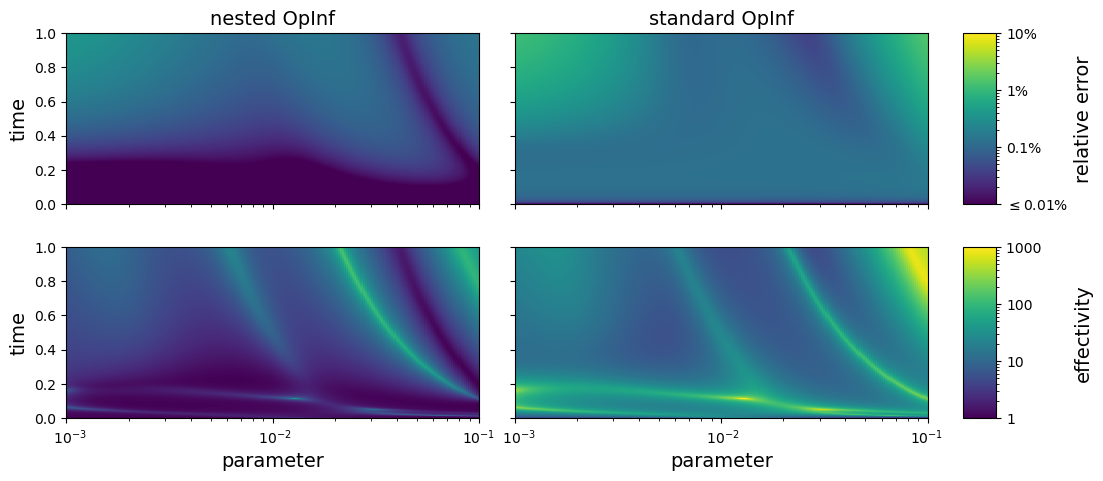

In [ ]:
# effectivity
n = 4

fig, axs = plt.subplots(2, 3, figsize=(12, 5), width_ratios=[1, 1, 0.08])
fontsize = 14

X, Y = np.meshgrid(Xi_test, grid_t)

# error
for i, i_model in enumerate([2, 1]):
    cs0 = axs[0, i].pcolormesh(X, Y, 100 * errors[:, i_model, n, :].T /reference_norm.T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs0.set_clim(vmin=1e-2, vmax=10)

    axs[0, i].set_xscale("log")
    axs[0, i].set_xlim(Xi_test[0, 0], Xi_test[-1, 0])
    axs[0, i].set_ylim(grid_t[0], grid_t[-1])
    axs[0, i].set_title(names[i_model], fontsize = fontsize)
    axs[0, i].set_xticklabels(["", "", ""])

# effectivity
for i, i_model in enumerate([2, 1]):
    cs = axs[1, i].pcolormesh(X, Y, errors[:, i_model, n, :].T / errors[:, -1, n, :].T, norm = colors.LogNorm(), cmap=plt.colormaps["viridis"])
    cs.set_clim(vmin=1, vmax=1000)

    axs[1, i].set_xscale("log")
    axs[1, i].set_xlim(Xi_test[0, 0], Xi_test[-1, 0])
    axs[1, i].set_ylim(grid_t[0], grid_t[-1])
    axs[1, i].set_xlabel("parameter", fontsize = fontsize)
    axs[1, i].set_xticks([1e-3, 1e-2, 1e-1], ["  $10^{-3}$", " $10^{-2}$", "$10^{-1}$ "])

axs[0, 0].set_ylabel("time", fontsize=fontsize)
axs[0, 1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])
axs[0, 2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])
axs[1, 0].set_ylabel("time", fontsize=fontsize)
axs[1, 1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])
axs[1, 2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["", "", "", "", "", ""])

cbar = fig.colorbar(cs, cax=axs[1, -1])
cbar.ax.set_yticks([1, 10, 100, 1000], [1, 10, 100, "1000      "])
cbar.ax.set_ylabel("effectivity", fontsize = fontsize)

cbar0 = fig.colorbar(cs0, cax=axs[0, -1])
cbar0.ax.set_yticks([0.01, 0.1, 1, 10], ["$\leq$0.01%", "0.1%", "1%", "10%"])
cbar0.ax.set_ylabel("relative error", fontsize = fontsize)

fig.subplots_adjust(hspace=0.25)
fig.subplots_adjust(wspace=0.25/2)

# fig.savefig(f"/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/error2D_effectivity2D_n{n+1}_opinf.png", bbox_inches = "tight")

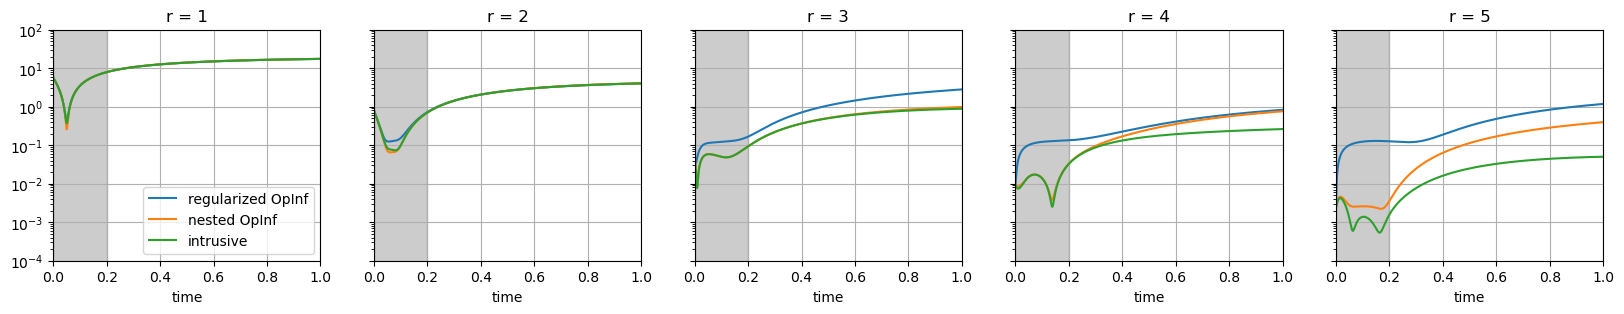

In [ ]:
i_test = 0

fig, axs = plt.subplots(1, nRB, sharey = True, sharex = True, figsize = (4*nRB, 3))

for j in range(nRB):
    rect = Rectangle((0, 1e-12), final_training_time, 200, color="k", alpha=0.2)
    axs[j].add_patch(rect)

    for i in [1, 2, 0]:
        axs[j].semilogy(grid_t, 100 * errors[i_test, i, j, :] / reference_norm[i_test, :], label = names[i])

    axs[j].set_xlabel("time")
    axs[j].set_title("r = {}".format(j + 1))
    axs[j].grid(True)

axs[0].set_ylim((1e-4, 1e+2))
axs[0].set_xlim((0, 1))
axs[0].legend()

In [ ]:
for n in range(nRB):
    print(f"Mean ROM compute time (r={n+1}):", np.mean(test_time[:, :, n], axis = 0))

Mean ROM compute time (r=1): [0.01308028 0.01299221 0.01301353]
Mean ROM compute time (r=2): [0.01459424 0.0144231  0.01453989]
Mean ROM compute time (r=3): [0.014941   0.01471133 0.01473292]
Mean ROM compute time (r=4): [0.01480861 0.01454975 0.0147571 ]
Mean ROM compute time (r=5): [0.01641506 0.01523298 0.01568975]


In [ ]:
for i in range(3):
    print(f"Mean speed-up ({names[i]})", np.mean(compute_time_fom / test_time[:, i, 4], axis = 0))

Mean speed-up (intrusive) 518.9082323114907
Mean speed-up (regularized OpInf) 539.3353305652802
Mean speed-up (nested OpInf) 525.8906489530285


In [ ]:
errors.shape

(201, 4, 5, 1001)

In [ ]:
i = 3
print(names[i])
print("training time, training parameters")
reconstruction = 100 * errors[[0, 100, 200], i, 4, :201] / reference_norm[[0, 100, 200], :201]
print(f"average error (%): {np.mean(reconstruction)}")
print(f"maximum error (%):  {np.max(reconstruction)}")

print("\n all time, training parameters")
reconstruction = 100 * errors[[0, 100, 200], i, 4, :] / reference_norm[[0, 100, 200], :]
print(f"average error (%): {np.mean(reconstruction)}")
print(f"maximum error (%):  {np.max(reconstruction)}")

print("\n training time, all parameters")
reconstruction = 100 * errors[:, i, 4, :201] / reference_norm[:, :201]
print(f"average error (%): {np.mean(reconstruction)}")
print(f"maximum error (%):  {np.max(reconstruction)}")

print("\n all time, all parameters")
reconstruction = 100 * errors[:, i, 4, :] / reference_norm[:, :]
print(f"average error (%): {np.mean(reconstruction)}")
print(f"maximum error (%):  {np.max(reconstruction)}")

projection
training time, training parameters
average error (%): 0.002474280343791156
maximum error (%):  0.007535402123714214

 all time, training parameters
average error (%): 0.012904325231414111
maximum error (%):  0.05002135941492469

 training time, all parameters
average error (%): 0.0035914260214623653
maximum error (%):  0.01386508308527932

 all time, all parameters
average error (%): 0.012413691431018396
maximum error (%):  0.05002135941492469


In [ ]:
i = 2
print(names[i])
print("training time, training parameters")
reconstruction = errors[[0, 100, 200], i, 4, :201] / errors[[0, 100, 200], -1, 4, :201]
print(f"average effectivity: {np.mean(reconstruction)}")
print(f"maximum effectivity:  {np.max(reconstruction)}")

print("\n all time, training parameters")
reconstruction = errors[[0, 100, 200], i, 4, :] / errors[[0, 100, 200], -1, 4, :]
print(f"average effectivity: {np.mean(reconstruction)}")
print(f"maximum effectivity:  {np.max(reconstruction)}")

print("\n training time, all parameters")
reconstruction = errors[:, i, 4, :201] / errors[:, -1, 4, :201]
print(f"average effectivity: {np.mean(reconstruction)}")
print(f"maximum effectivity:  {np.max(reconstruction)}")

print("\n all time, all parameters")
reconstruction = errors[:, i, 4, :] / errors[:, -1, 4, :]
print(f"average effectivity: {np.mean(reconstruction)}")
print(f"maximum effectivity:  {np.max(reconstruction)}")

nested OpInf
training time, training parameters
average effectivity: 2.100806730863321
maximum effectivity:  7.230004142763489

 all time, training parameters
average effectivity: 11.760109631848959
maximum effectivity:  90.72660165873823

 training time, all parameters
average effectivity: 1.8271935560940842
maximum effectivity:  34.70566528847716

 all time, all parameters
average effectivity: 7.507506854763201
maximum effectivity:  136.39304161415325


### comparison for different reduced dimensions

In [19]:
error_at_time_02 = errors[:, :, :, 200] # parameter x model x dimension 
error_at_time_10 = errors[:, :, :, 1000]

relative_error_at_time_02 = np.zeros(error_at_time_02.shape)
relative_error_at_time_10 = np.zeros(error_at_time_10.shape)

for n in range(5):
    relative_error_at_time_02[:, :, n] = (error_at_time_02[:, :, n].T / reference_norm[:, 200]).T # parameter x model x dimension 
    relative_error_at_time_10[:, :, n] = (error_at_time_10[:, :, n].T / reference_norm[:, 1000]).T

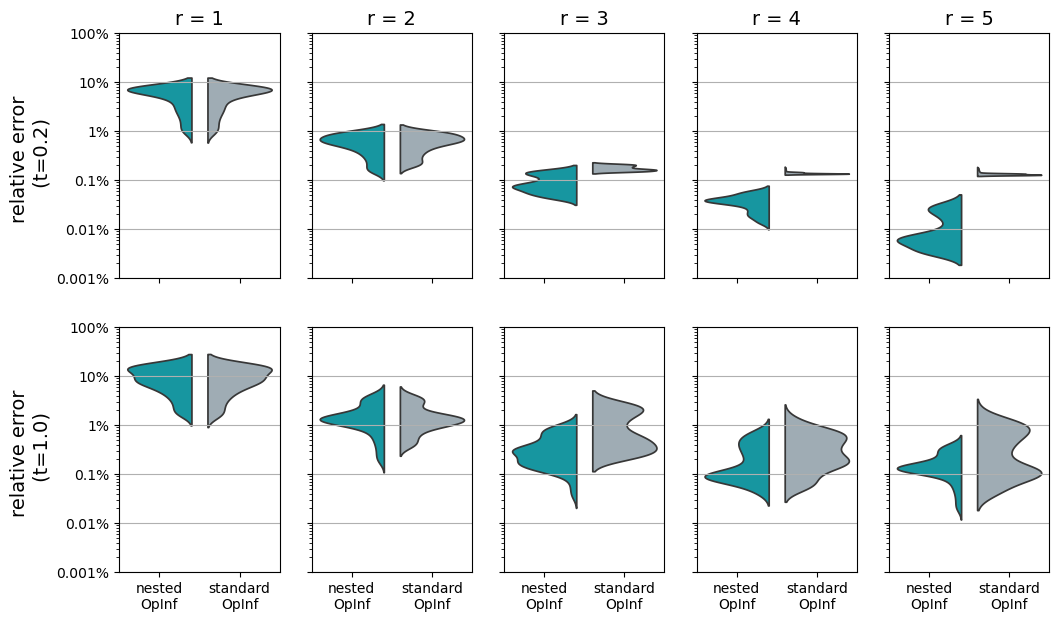

In [ ]:
fig, axs = plt.subplots(2, 5, sharex = True, sharey = True, figsize=(12, 7))
my_pal = {"nested\nOpInf": "#00a9b7", "standard\nOpInf": "#9cadb7"}

for n in range(5):

    axs[1, n].grid(True)
    axs[0, n].grid(True)

    # top row: final time 0.2
    data = pd.DataFrame(100 * relative_error_at_time_02[:, [2, 1], n], columns = ["nested\nOpInf", "standard\nOpInf"])
    sns.violinplot(data, log_scale=True, ax=axs[0, n], split=True, palette=my_pal, alpha=1, inner = None)

    
    axs[0, n].set_title(f"r = {n+1}", fontsize=fontsize)

    # bottom row: final time 1.0
    data = pd.DataFrame(100 * relative_error_at_time_10[:, [2, 1], n], columns = ["nested\nOpInf", "standard\nOpInf"])
    sns.violinplot(data, log_scale=True, ax=axs[1, n], split=True, palette=my_pal, inner = None)

    

axs[0, 0].set_ylabel("relative error \n (t=0.2)", fontsize=fontsize)
axs[0, 0].set_ylim(1e-3, 1e+2)
axs[0, 0].set_yticks([1e-3, 1e-2, 1e-1, 1, 10, 100], ["0.001%", "0.01%", "0.1%", "1%", "10%", "100%"])

axs[1, 0].set_ylabel("relative error \n (t=1.0)", fontsize=fontsize)

# fig.savefig(f"/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/error_over_dimension_trn.png", bbox_inches = "tight")

Text(0, 0.5, 'effectivity')

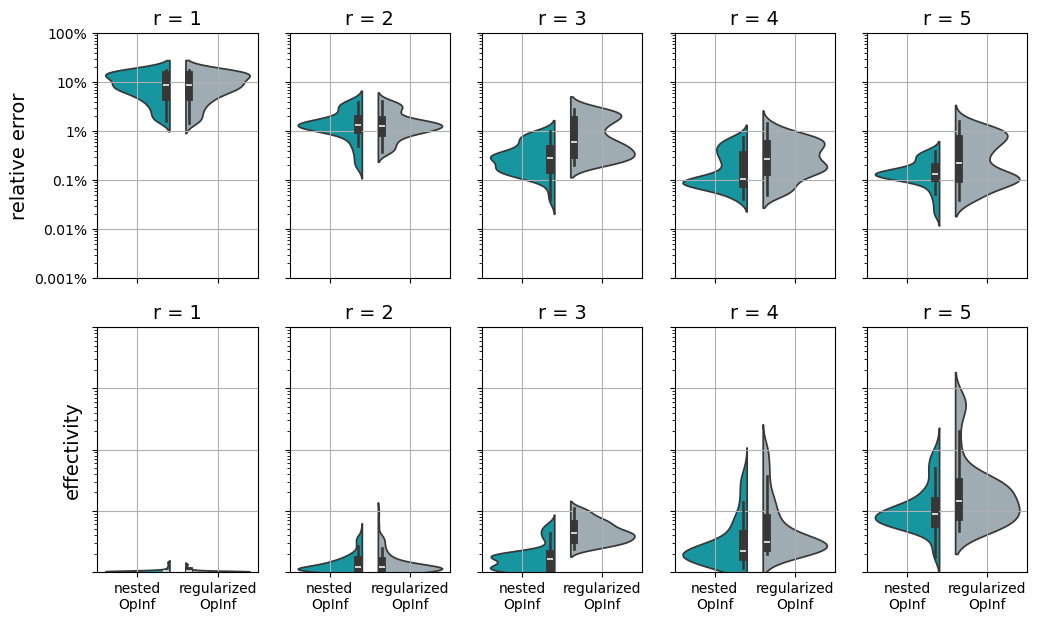

In [ ]:
fig, axs = plt.subplots(2, 5, sharex = True, sharey = False, figsize=(12, 7))



for n in range(5):

    # top row: final time 0.2
    data = pd.DataFrame(100 * relative_error_at_time_10[:, [2, 1], n], columns = ["nested\nOpInf", "regularized\nOpInf"])
    sns.violinplot(data, log_scale=True, ax=axs[0, n], split=True, palette=my_pal)

    axs[0, n].grid(True)
    axs[0, n].set_title(f"r = {n+1}", fontsize=fontsize)
    axs[0, n].set_ylim(1e-3, 1e+2)
    axs[0, n].set_yticklabels([])

    # top row: final time 0.2
    data = pd.DataFrame((relative_error_at_time_10[:, [2, 1], n].T / relative_error_at_time_10[:, -1, n]).T, columns = ["nested\nOpInf", "regularized\nOpInf"])
    sns.violinplot(data, log_scale=True, ax=axs[1, n], split=True, palette=my_pal)

    axs[1, n].grid(True)
    axs[1, n].set_title(f"r = {n+1}", fontsize=fontsize)
    axs[1, n].set_ylim(1, 1e+4)
    axs[1, n].set_yticklabels([])

axs[0, 0].set_ylabel("relative error", fontsize=fontsize)

axs[0, 0].set_yticks([1e-3, 1e-2, 1e-1, 1, 10, 100], ["0.001%", "0.01%", "0.1%", "1%", "10%", "100%"])

axs[1, 0].set_ylabel("effectivity", fontsize=fontsize)

In [ ]:
reference_norm.shape

(201, 1001)

In [ ]:
errors.shape

(201, 4, 5, 1001)

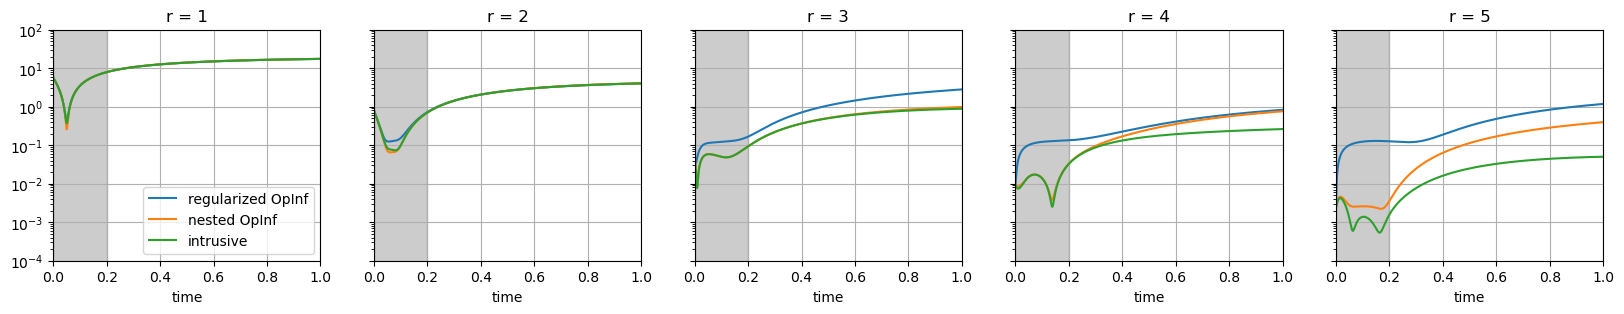

In [ ]:
i_test = 0

fig, axs = plt.subplots(1, nRB, sharey = True, sharex = True, figsize = (4*nRB, 3))

for j in range(nRB):
    rect = Rectangle((0, 1e-12), final_training_time, 200, color="k", alpha=0.2)
    axs[j].add_patch(rect)

    for i in [1, 2, 0]:
        axs[j].semilogy(grid_t, 100 * errors[i_test, i, j, :] / reference_norm[i_test, :], label = names[i])

    axs[j].set_xlabel("time")
    axs[j].set_title("r = {}".format(j + 1))
    axs[j].grid(True)

axs[0].set_ylim((1e-4, 1e+2))
axs[0].set_xlim((0, 1))
axs[0].legend()